# Random Forest

Dataset Description:

Use the Glass dataset and apply the Random forest model.

1. Exploratory Data Analysis (EDA):


In [1]:
# Perform exploratory data analysis to understand the structure of the dataset.
# Check for missing values, outliers, inconsistencies in the data.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [4]:
df=pd.read_excel('glass.xlsx')

In [5]:
df.head()


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [6]:
df.columns

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')

In [7]:
df.shape


(214, 10)

In [8]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [30]:
## no missing data
df_cleaned = df.dropna(axis=1)

In [31]:
df_cleaned.duplicated().sum()

np.int64(0)

In [32]:
df_cleaned.drop_duplicates(inplace=True,ignore_index=True)

In [33]:
df_cleaned.duplicated().sum()

np.int64(0)

In [13]:
## now no duplicated data

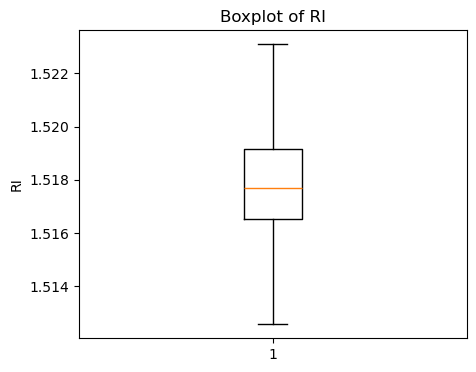

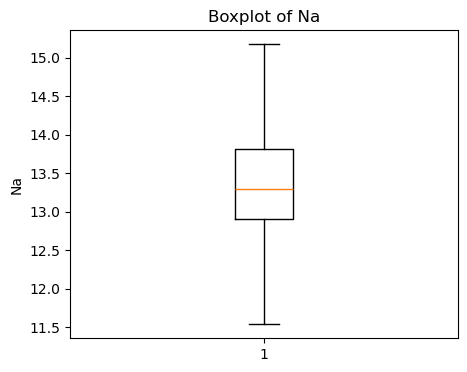

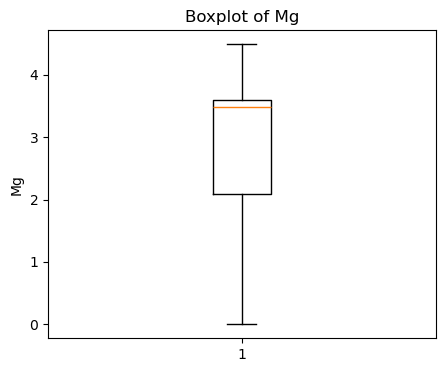

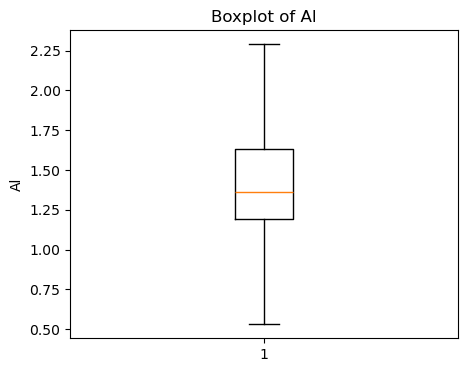

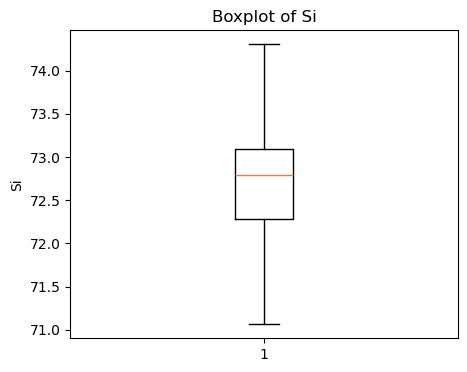

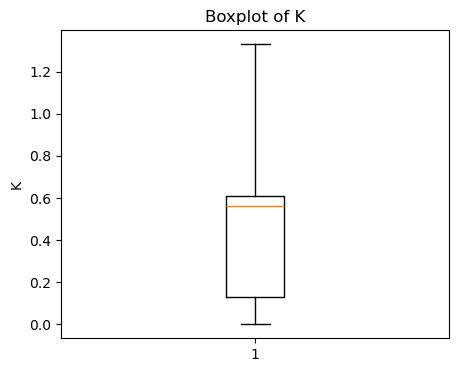

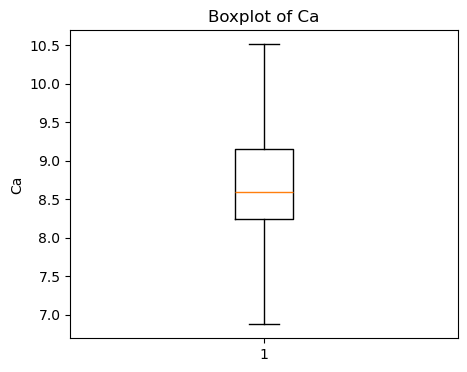

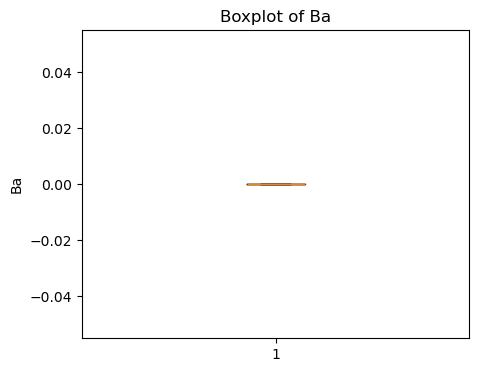

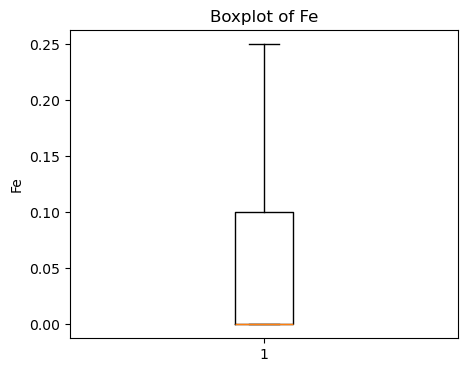

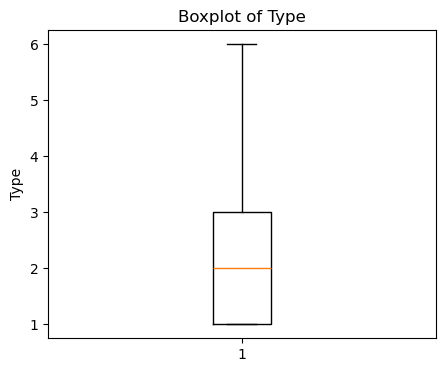

In [34]:
### checking for outliers
for col in df:
    plt.figure(figsize=(5,4))
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()


In [35]:
## outlier capping
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25)
    Q3= df[columns].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[columns]= df[columns].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df:
    outlier_capping(df,col)


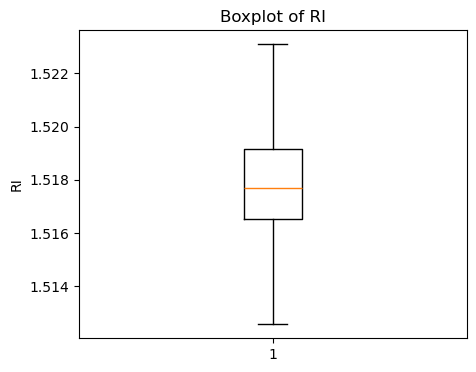

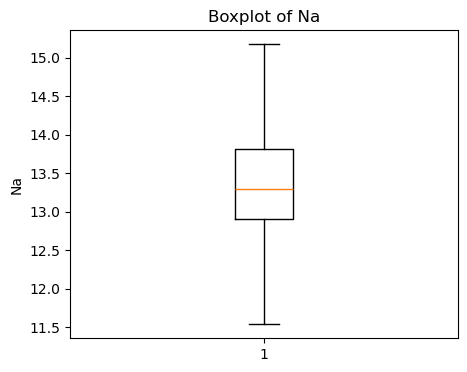

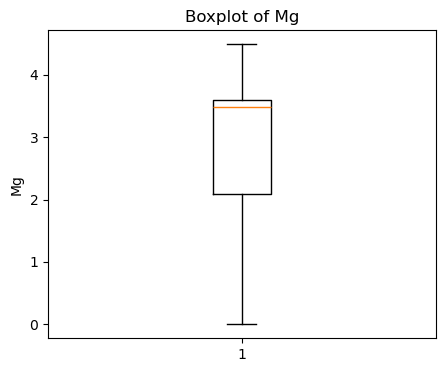

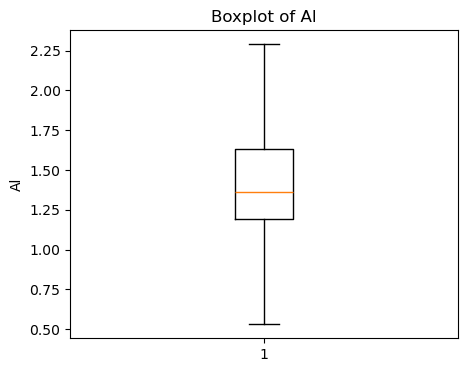

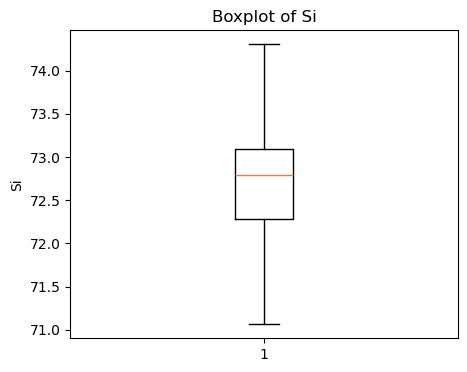

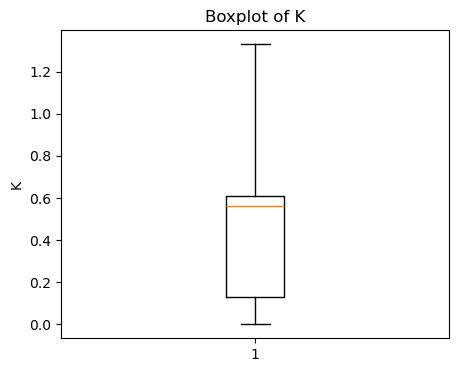

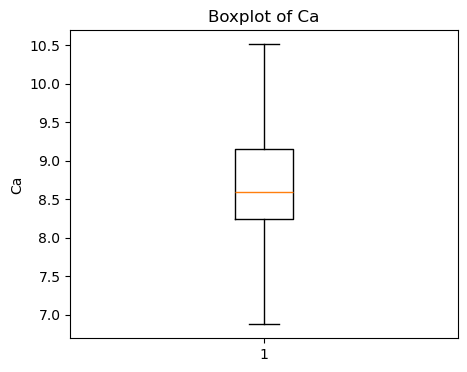

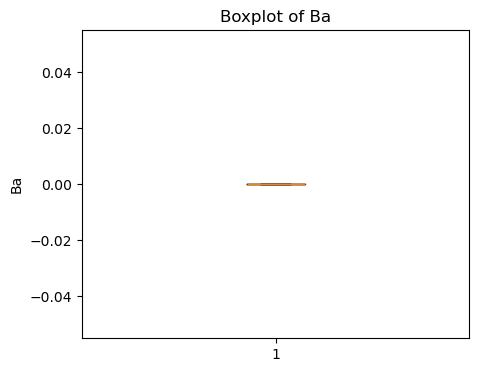

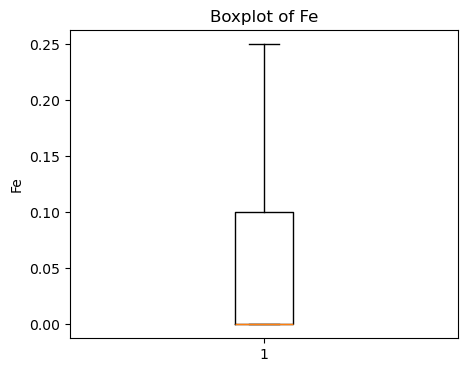

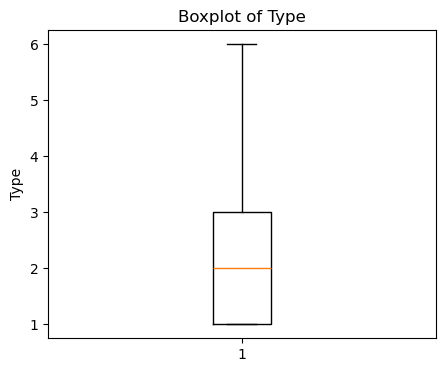

In [36]:
### checking for outliers after capping
for col in df:
    plt.figure(figsize=(5,4))
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

In [37]:
## there are no outliers now

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      213 non-null    float64
 1   Na      213 non-null    float64
 2   Mg      213 non-null    float64
 3   Al      213 non-null    float64
 4   Si      213 non-null    float64
 5   K       213 non-null    float64
 6   Ca      213 non-null    float64
 7   Ba      213 non-null    float64
 8   Fe      213 non-null    float64
 9   Type    213 non-null    float64
dtypes: float64(10)
memory usage: 16.8 KB


2: Data Visualization:

Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.

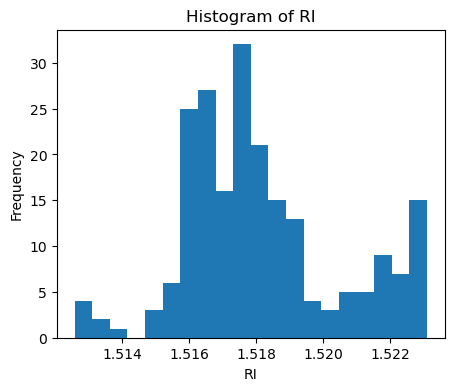

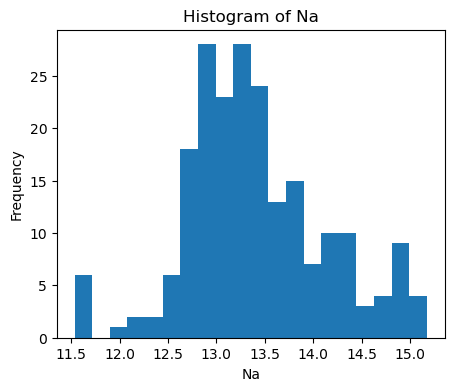

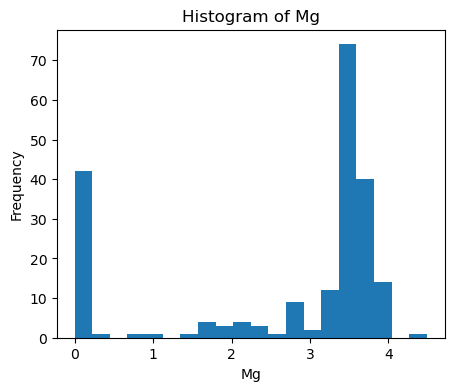

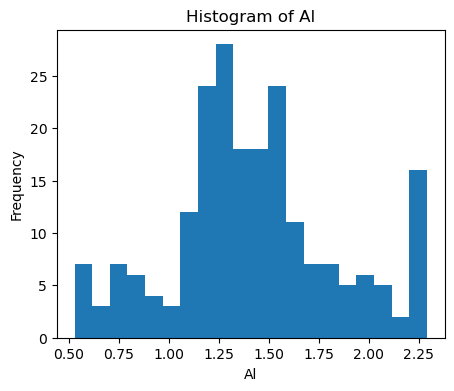

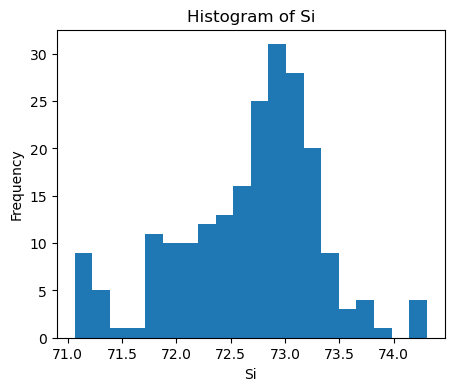

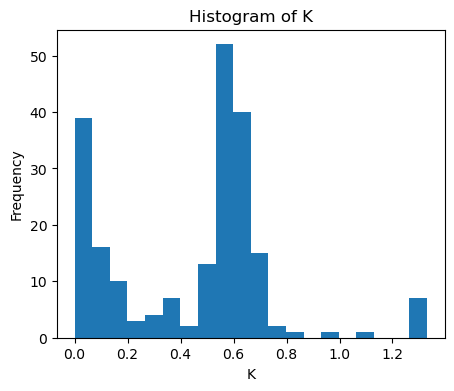

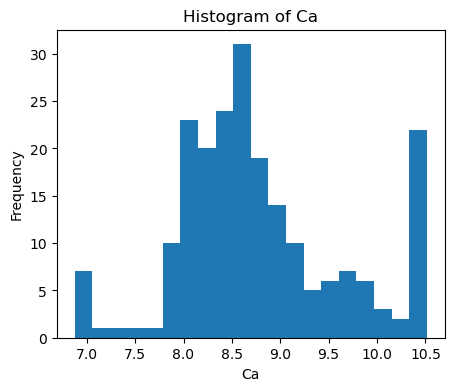

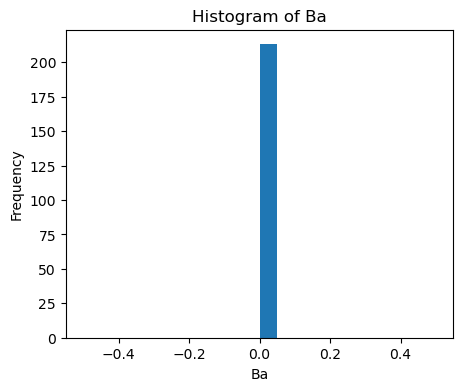

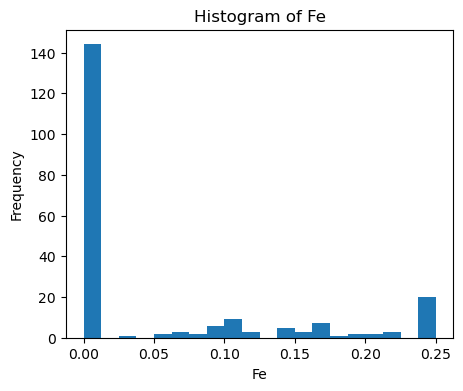

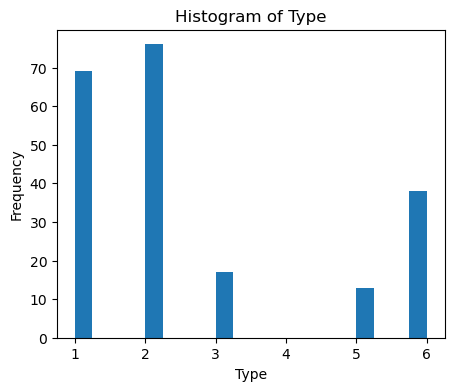

In [39]:
## histogram for numerical columns
for col in df:
    plt.figure(figsize=(5,4))
    plt.hist(df[col].dropna(), bins=20)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [40]:
### finding skewness  for the data distribution
for col in df:
    skewness = df[col].skew()
    print(f"skewness for {col}:", skewness)
             

skewness for RI: 0.5224992453689132
skewness for Na: 0.2343772859603613
skewness for Mg: -1.1460958436967303
skewness for Al: 0.22653108188765803
skewness for Si: -0.5018186418037746
skewness for K: 0.3324142458052551
skewness for Ca: 0.46372244531449014
skewness for Ba: 0.0
skewness for Fe: 1.3071597775340815
skewness for Type: 0.9592781444005314


In [41]:
### based on the skewness values data is not normally distrubuted, it is having moderately negative and positive skewed.

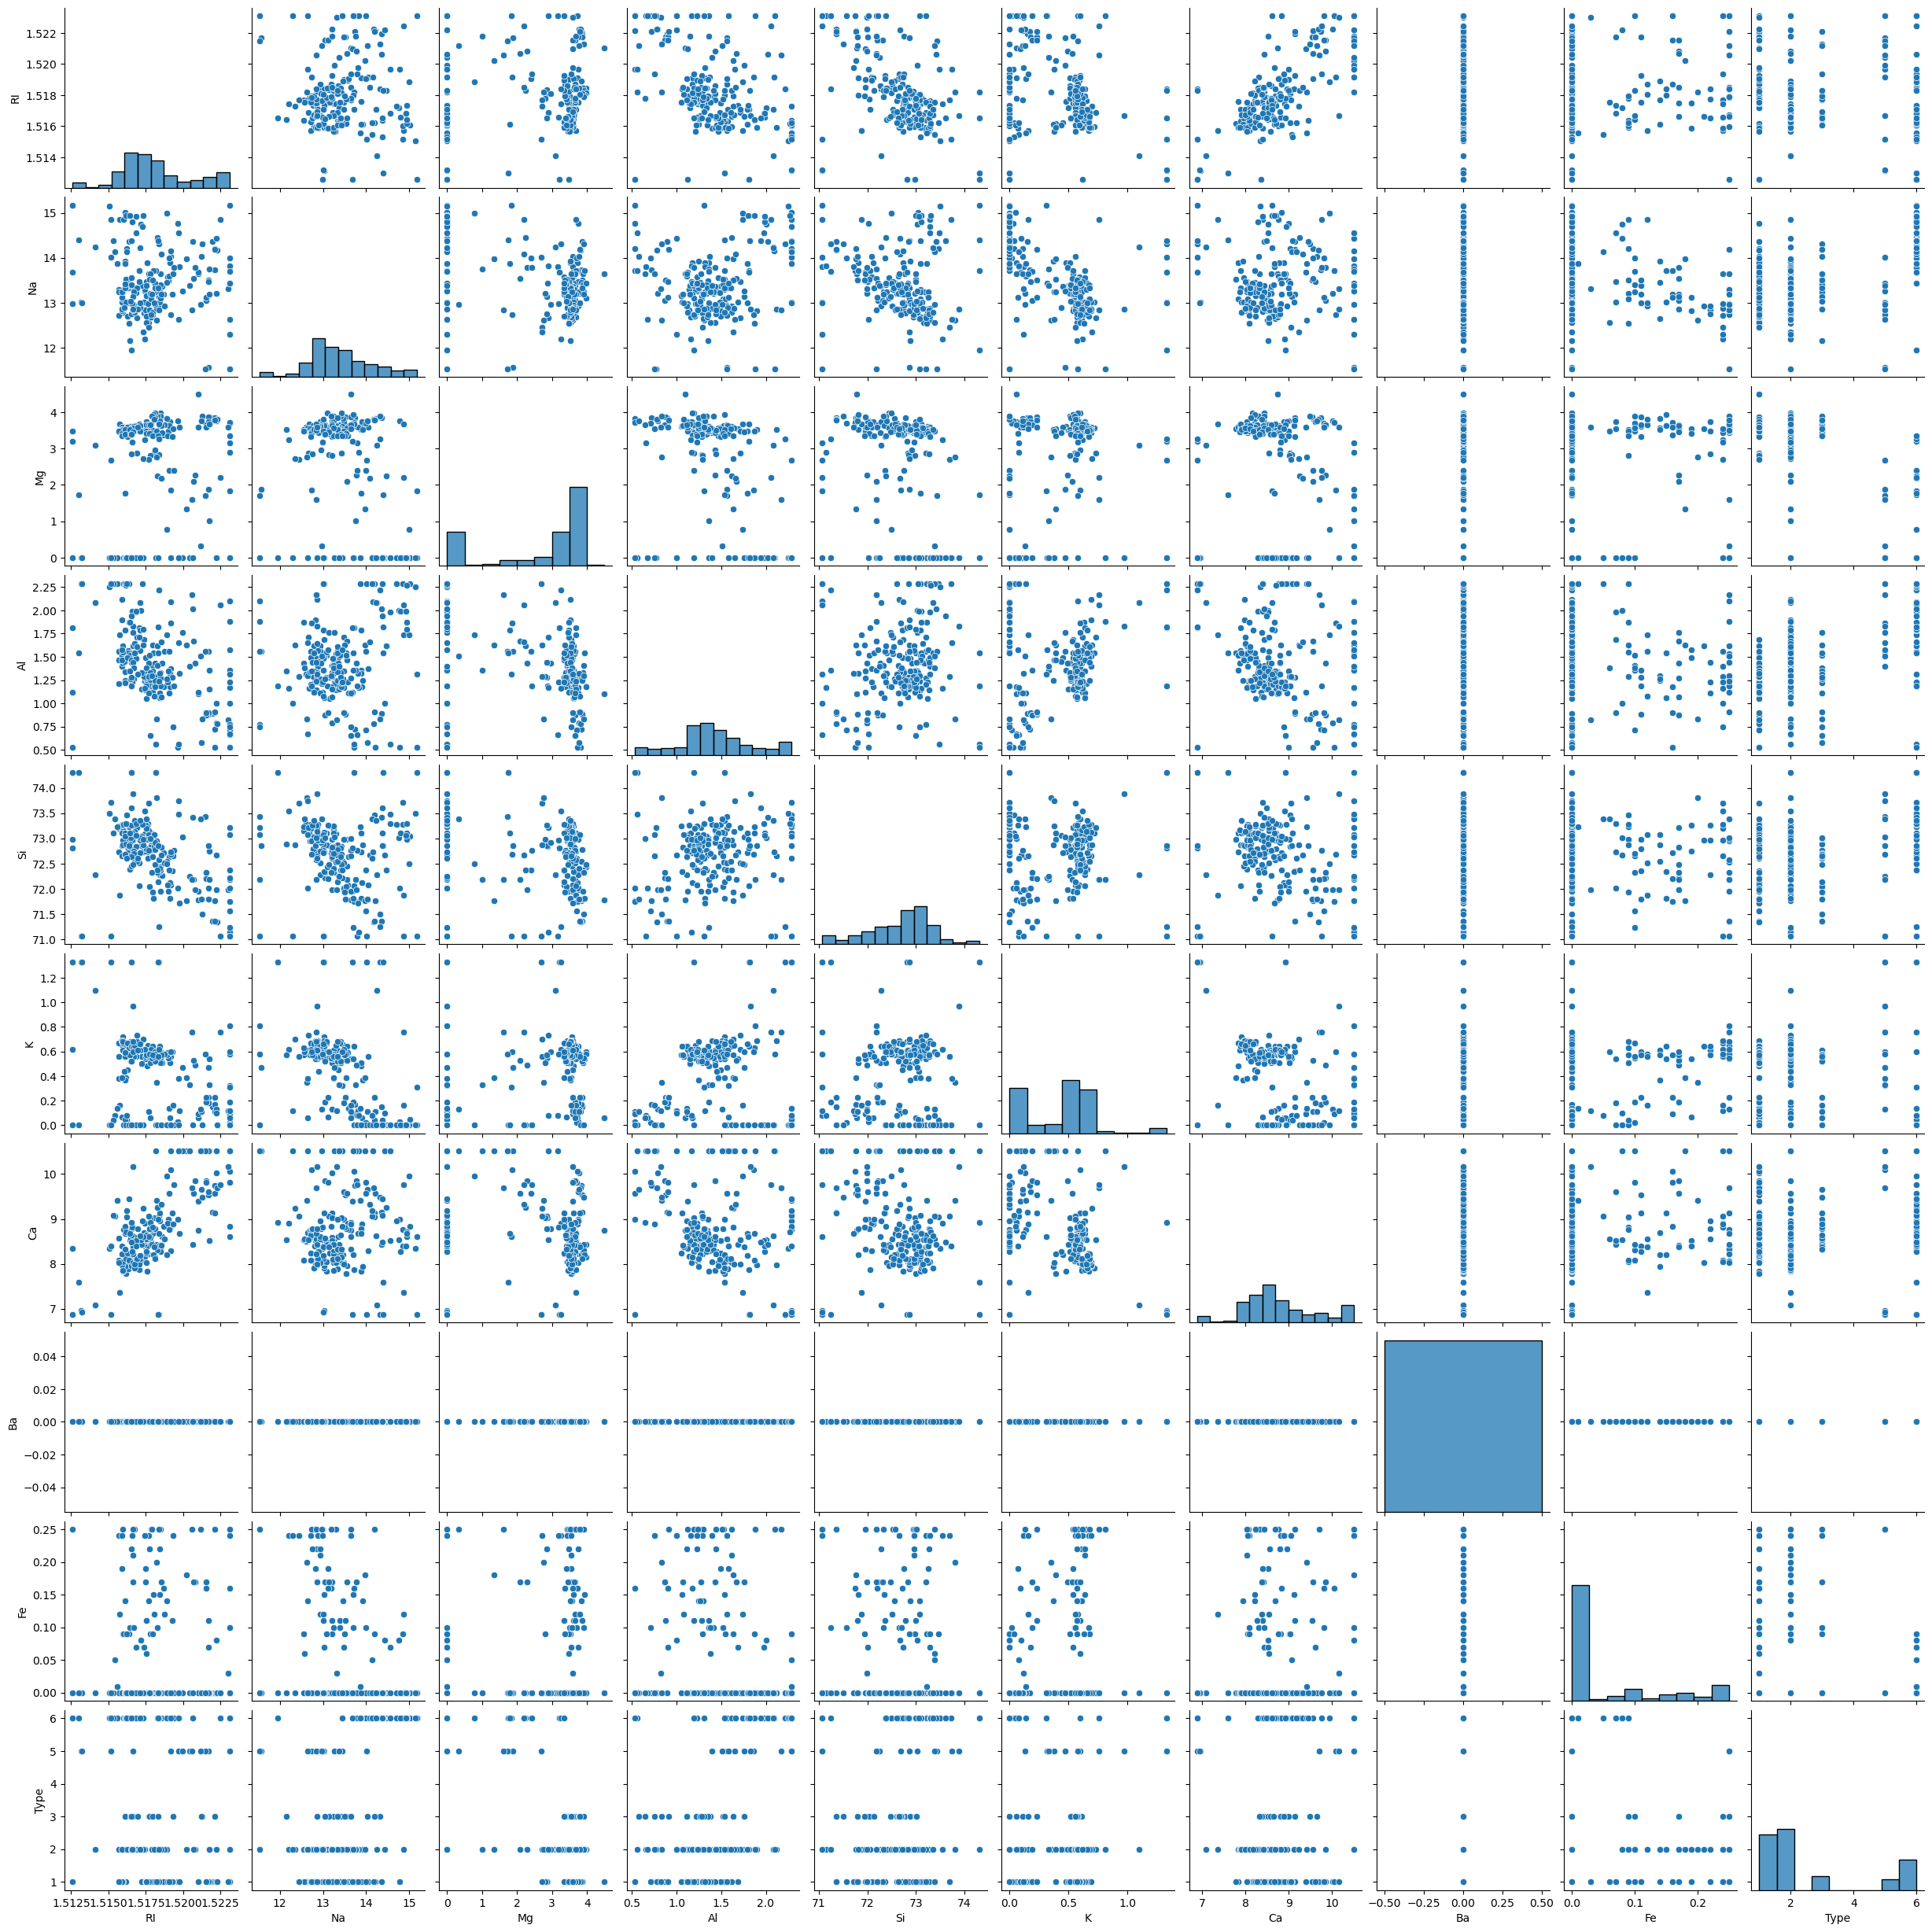

In [42]:
## pair plot 
sns.pairplot(df)
plt.show()

In [43]:
df_corr = df.corr()

In [44]:
df_corr

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
RI,1.000000,-0.072901,-0.038895,-0.461848,-0.526911,-0.339382,0.760626,NaN,0.100217,-0.155095
Na,-0.072901,1.000000,-0.300589,0.223172,-0.158794,-0.492717,-0.103610,NaN,-0.249138,0.503702
Mg,-0.038895,-0.300589,1.000000,-0.472330,-0.206544,0.334363,-0.372089,NaN,0.104381,-0.739870
Al,-0.461848,0.223172,-0.472330,1.000000,0.130631,0.173969,-0.277706,NaN,-0.096567,0.585616
Si,-0.526911,-0.158794,-0.206544,0.130631,1.000000,-0.040748,-0.188686,NaN,-0.068593,0.166276
K,-0.339382,-0.492717,0.334363,0.173969,-0.040748,1.000000,-0.497856,NaN,0.076522,-0.243427
Ca,0.760626,-0.103610,-0.372089,-0.277706,-0.188686,-0.497856,1.000000,NaN,0.106853,0.073455
Ba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe,0.100217,-0.249138,0.104381,-0.096567,-0.068593,0.076522,0.106853,NaN,1.000000,-0.219217
Type,-0.155095,0.503702,-0.739870,0.585616,0.166276,-0.243427,0.073455,NaN,-0.219217,1.000000


3: Data Preprocessing

In [45]:
# 1. Check for missing values in the dataset and decide on a strategy for handling them.
#      Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.
#  It has been taken cere of in orevious steps.there is no missing data to handle.


In [46]:
# 2. If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.
df_categorial = df.select_dtypes(include=['object','character'])

In [47]:
df_categorial.head()

""
0
1
2
3
4


In [48]:
### there is no categorial data to encode.

In [69]:
# 3. Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale. 
#     Handling the imbalance data.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score,recall_score,f1_score

In [51]:
# Separate features and target
features = df.drop('Type', axis=1)
target = df['Type']


In [52]:
features.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0


In [55]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42, stratify=target)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
   

(170, 9)
(43, 9)
(170,)
(43,)


In [56]:
## Feature scaling, standarization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
## Normalization( Min-Max scaling)
normalizer = MinMaxScaler()
X_train_normalized = normalizer.fit_transform(X_train)
X_test_normalized = normalizer.transform(X_test)


In [62]:
# 4: Random Forest Model Implementation
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)  # Using scaled data

RandomForestClassifier(random_state=42)

In [71]:
# Train the model on the train dataset. Evaluate the performance on test data using metrics like accuracy, precision, recall, and F1-score.
## make the predictions
y_pred = rf_model.predict(X_test)

# evaluate the performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')  # Use 'weighted' for multi-class
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Random Forest Model Performance on Test Data:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# Detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Random Forest Model Performance on Test Data:
Accuracy : 0.3488
Precision: 0.1246
Recall   : 0.3488
F1-score : 0.1836

Classification Report:

              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00        14
         2.0       0.36      1.00      0.53        15
         3.0       0.00      0.00      0.00         3
         5.0       0.00      0.00      0.00         3
         6.0       0.00      0.00      0.00         8

    accuracy                           0.35        43
   macro avg       0.07      0.20      0.11        43
weighted avg       0.12      0.35      0.18        43



5: Bagging and Boosting Methods

In [72]:
# Apply the Bagging and Boosting methods and compare the results.

In [79]:
# Bagging
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier

# Bagging
bag_rf_model = BaggingClassifier(estimator=RandomForestClassifier(n_estimators=50, random_state=42),
                                   n_estimators=10,  # Number of Random Forests to bag
                                   random_state=42,
                                   n_jobs=-1)


In [80]:
# # Train the model
bag_rf_model.fit(X_train, y_train)


BaggingClassifier(estimator=RandomForestClassifier(n_estimators=50,
                                                   random_state=42),
                  n_jobs=-1, random_state=42)

In [81]:
# Make predictions
y_pred_bag_rf = bag_rf_model.predict(X_test)

In [82]:
# Evaluate performance
accuracy = accuracy_score(y_test, y_pred_bag_rf)
precision = precision_score(y_test, y_pred_bag_rf, average='weighted')
recall = recall_score(y_test, y_pred_bag_rf, average='weighted')
f1 = f1_score(y_test, y_pred_bag_rf, average='weighted')

print("Bagging with Random Forest Performance:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Bagging with Random Forest Performance:
Accuracy : 0.8372
Precision: 0.8444
Recall   : 0.8372
F1-score : 0.8352


In [83]:
# Boosting with Random forest
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [84]:
# Initialize AdaBoost with Random Forest as the base estimator
boost_rf_model = AdaBoostClassifier(
    estimator=RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42),
    n_estimators=10,  # Number of boosting rounds
    learning_rate=0.5,
    random_state=42)


In [85]:
# Train the model
boost_rf_model.fit(X_train, y_train)

AdaBoostClassifier(estimator=RandomForestClassifier(max_depth=3,
                                                    n_estimators=50,
                                                    random_state=42),
                   learning_rate=0.5, n_estimators=10, random_state=42)

In [86]:
# Make predictions
y_pred_boost_rf = boost_rf_model.predict(X_test)

In [87]:
# Evaluate performance
accuracy = accuracy_score(y_test, y_pred_boost_rf)
precision = precision_score(y_test, y_pred_boost_rf, average='weighted')
recall = recall_score(y_test, y_pred_boost_rf, average='weighted')
f1 = f1_score(y_test, y_pred_boost_rf, average='weighted')


In [88]:
print("Boosting with Random Forest Performance:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Boosting with Random Forest Performance:
Accuracy : 0.7674
Precision: 0.7864
Recall   : 0.7674
F1-score : 0.7706


Bagging with Random Forest Performance:
Accuracy : 0.8372,
Precision: 0.8444,
Recall   : 0.8372,
F1-score : 0.8352

Boosting with Random Forest Performance:
Accuracy : 0.7674,
Precision: 0.7864,
Recall   : 0.7674,
F1-score : 0.7706

# Additional Notes:

 1. Explain Bagging and Boosting methods. How is it different from each other.

Bagging and Boosting are two core ensemble learning methods used to improve model performance by combining multiple learners. 
While both use many models, they work in very different ways and solve different problems.

Bagging builds many independent models to reduce variance, while Boosting builds models sequentially to reduce bias by focusing on mistakes.    
           
Bagging = Bootstrap Aggregating

Bagging reduces variance by training many models independently on different random samples of the dataset and then combining their predictions.
    
How it works:

Create multiple datasets using bootstrap sampling (sampling with replacement).

Train a model on each sampled dataset.

Combine predictions using:

Voting (classification)

Averaging (regression)

Best for:

High-variance models (e.g., Decision Trees)

Reducing overfitting

Example:

BaggingClassifier

Random Forest (bagging + feature randomness)

Boosting:

Boosting reduces bias and improves weak learners by training models sequentially, where each new model focuses more on the mistakes of the previous ones.

How it works:

Train a first weak model.

Increase weight of misclassified samples.

Train the next model focusing more on hard samples.

Repeat sequentially.

Combine models using weighted voting.  

Best for:

Improving weak models

Reducing bias

Learning complex patterns

Example:

AdaBoost

Gradient Boosting

XGBoost, LightGBM, CatBoost
    
        

2.Explain how to handle imbalance in the data

Imbalanced data: A dataset is imbalanced when the number of observations in one class is much larger than the others.

Example:

95% → Class 0

5% → Class 1

Problems with Imbalanced Data: 

Biased predictions toward majority class

Poor recall for minority class

Misleading accuracy

Model ignores rare but important cases

So, instead of accuracy, metrics like Precision, Recall, F1-score, ROC-AUC become more important.

Techniques to Handle Imbalanced Data:

Data-Level Methods (Resampling):

Oversampling

Increase minority samples.

Random Oversampling

SMOTE (Synthetic Minority Oversampling Technique)

ADASYN

Undersampling:

Reduce majority samples.

Random Undersampling

NearMiss

Hybrid Sampling:

Combine both.

Algorithm-Level Methods:
Class Weights - 

Give higher penalty to minority class.

Threshold Tuning - 

Instead of default 0.5 cutoff, adjust decision threshold.

Use Specialized Algorithms

Some models handle imbalance better:

XGBoost (scale_pos_weight)

LightGBM (is_unbalance=True)

CatBoost (class_weights)

Evaluation-Level Methods

Never rely only on accuracy.

Use:

Precision

Recall

F1-score

ROC-AUC

PR-AUC

Confusion Matrix

Cross-Validation with Stratification

Ensure class distribution is preserved.

Ensemble Techniques

Balanced Random Forest

EasyEnsemble

Boosting with reweighting

These naturally improve minority detection.

Imbalanced data can be handled using resampling techniques like SMOTE and undersampling, assigning class weights, tuning decision thresholds, 
using appropriate metrics such as F1-score and ROC-AUC instead of accuracy, and applying ensemble methods that focus on minority classes.